# Redes Neuronales Recurrentes

En este notebook exploraremos distintas arquitecturas de redes neuronales aplicadas a datos del mundo real. Hasta ahora hemos trabajado siempre con el mismo tipo de modelo: el **Perceptrón Multicapa** (MLP), una red *feed-forward* de la que ya conocemos bien su estructura y funcionamiento.

![](https://www.researchgate.net/profile/Mohamed_Zahran6/publication/303875065/figure/fig4/AS:371118507610123@1465492955561/A-hypothetical-example-of-Multilayer-Perceptron-Network.png)

El MLP es un modelo poderoso y versátil, pero tiene una limitación importante: no está diseñado para capturar dependencias temporales en **datos secuenciales**, como series de precios financieros. En este notebook trabajaremos con el dataset `USD_RUB_Historical_Data.csv`, que contiene el historial del tipo de cambio **dólar estadounidense / rublo ruso (USD/RUB)**. Este tipo de datos, en el que cada observación depende de las anteriores, requiere una arquitectura diferente: las **Redes Neuronales Recurrentes** (RNN).


## Definición

En una red neuronal *feed forward* la información viaja en un único sentido: desde la capa de entrada hacia la salida, sin volver atrás. El `MLP` es el ejemplo por excelencia de este tipo. En cambio, una **red recurrente** añade conexiones hacia atrás entre las neuronas, permitiendo que la información de pasos anteriores influya en el procesamiento actual.

![](https://miro.medium.com/max/2544/1*aIT6tmnk3qHpStkOX3gGcQ.png)


La imagen anterior muestra la `RNN` más simple posible: una entrada, una neurona oculta y una salida. En un `MLP` estándar, la salida se calcula como:

$$ \mathbf{y} = \mathbf{W}_y \mathbf{h} = \mathbf{W}_y f(\mathbf{W}_x \mathbf{x}) $$

En una `RNN`, además de la entrada $\mathbf{x}_t$ del instante actual, se incorpora también el estado oculto del instante anterior $\mathbf{h}_{t-1}$, con su propia matriz de pesos:

$$ \mathbf{y}_t = \mathbf{W}_y \mathbf{h}_t = \mathbf{W}_y f(\mathbf{W}_x \mathbf{x}_t + \mathbf{W}_h \mathbf{h}_{t-1}) $$

En nuestro caso, el dataset USD/RUB está compuesto por una secuencia de precios diarios. Cada elemento $\mathbf{x}_t$ representa el precio (y otras características) del día $t$, y la red deberá aprender a utilizar el contexto de los días anteriores para predecir el valor del día siguiente.


## Tipos de RNNs


Las `RNN` abren un nuevo abanico de posibilidades según cómo configuremos las entradas y salidas:

![](https://i.stack.imgur.com/b4sus.jpg)

La configuración *one-to-one* equivale al `MLP` clásico. Las demás permiten trabajar con secuencias: *many-to-one* es ideal para predecir un único valor futuro a partir de una ventana de valores pasados (que es exactamente lo que haremos con el precio USD/RUB), mientras que *many-to-many* permite predecir varios pasos hacia el futuro de forma simultánea.


## Entrenando RNNs

El entrenamiento de las `RNN` sigue el mismo algoritmo que ya conocemos: **backpropagation**. La diferencia es que ahora los gradientes pueden fluir desde múltiples salidas a lo largo del tiempo, lo que se conoce como *backpropagation through time* (BPTT). Esto puede provocar problemas como el **desvanecimiento** o la **explosión del gradiente**, de los que hablaremos más adelante.

![](https://s3.ap-south-1.amazonaws.com/techleer/191.png)

En la práctica, frameworks como PyTorch ya manejan este proceso internamente, por lo que podemos entrenar una `RNN` con los mismos ingredientes que usamos para el `MLP`: un optimizador, una función de pérdida y el bucle de entrenamiento habitual.


## Predicción de series temporales

Ahora que ya tenemos la base teórica, vamos a aplicarla a un problema real. Trabajaremos con el dataset `USD_RUB_Historical_Data.csv`, que contiene precios históricos diarios del tipo de cambio dólar/rublo.Cargaremos los datos, los normalizaremos y construiremos ventanas deslizantes de `n_steps` días para predecir el precio del día siguiente.


In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x$"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(15, 8))
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row * c
            if ix >= len(series):
                break
            s = series[ix, :, 0]
            plt.plot(s, ".-")
            if y is not None:
                plt.plot([len(s)], y[ix], "bx", markersize=10)
            if y_pred is not None:
                plt.plot([len(s)], y_pred[ix], "ro")
            plt.grid(True)
            plt.hlines(0, 0, len(s) + 2, linewidth=1)
            plt.ylim(s.min() - 0.05, s.max() + 0.05)
            if row == r - 1:
                plt.xlabel(x_label if x_label else "Paso de tiempo", fontsize=12)
            if col == 0:
                plt.ylabel(y_label if y_label else "Precio", fontsize=12, rotation=0, labelpad=40)

    legend_items = [Line2D([0], [0], color='steelblue', marker='.', linestyle='-', label='Historial de precios')]
    if y is not None:
        legend_items.append(Line2D([0], [0], color='blue', marker='x', linestyle='None', markersize=10, label='Precio real del día siguiente'))
    if y_pred is not None:
        legend_items.append(Line2D([0], [0], color='red', marker='o', linestyle='None', markersize=6, label='Predicción del modelo'))
    fig.legend(handles=legend_items, loc='lower center', ncol=len(legend_items), fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.01))

    plt.suptitle("Ventanas de series temporales — USD/RUB", fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


In [2]:
def plot_series_forecast(series, y=None, y_pred=None, y_pred_std=None, x_label="$t$", y_label="$x$"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=False, sharex=True, figsize=(20, 10))  # sharey=False
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row*c
            if ix >= len(series):
                break
            s = series[ix, :, 0]
            plt.plot(s, ".-", linewidth=2, markersize=6)
            
            all_vals = list(s)  # colectar todos los valores para ylim
            
            if y is not None:
                y_plot = np.atleast_1d(y[ix])
                all_vals.extend(y_plot)
                plt.plot(range(len(s), len(s) + len(y_plot)), y_plot, "bx", markersize=10, linewidth=2)
            if y_pred is not None:
                y_p = np.atleast_1d(y_pred[ix])
                all_vals.extend(y_p)
                plt.plot(range(len(s), len(s) + len(y_p)), y_p, "ro", markersize=8, linewidth=2)
            if y_pred_std is not None:
                y_p = np.atleast_1d(y_pred[ix])
                y_s = np.atleast_1d(y_pred_std[ix])
                plt.plot(range(len(s), len(s) + len(y_p)), y_p + y_s, "--", alpha=0.5)
                plt.plot(range(len(s), len(s) + len(y_p)), y_p - y_s, "--", alpha=0.5)
                all_vals.extend(y_p + y_s)
                all_vals.extend(y_p - y_s)
            margin = (max(all_vals) - min(all_vals)) * 0.15
            plt.ylim(min(all_vals) - margin, max(all_vals) + margin)
            plt.grid(True, alpha=0.3)
            if x_label and row == r - 1:
                plt.xlabel(x_label, fontsize=14)
            if y_label and col == 0:
                plt.ylabel(y_label, fontsize=14, rotation=0, labelpad=30)
    plt.tight_layout()
    plt.show()

---

### Dataset real: USD/RUB

Una vez visto el ejemplo con datos sintéticos, replicamos el mismo flujo pero ahora con el dataset `USD_RUB_Historical_Data.csv`. Las series ya no son señales sinusoidales controladas, sino el precio histórico real del tipo de cambio dólar/rublo, lo que introduce mayor irregularidad y ruido real de mercado.


In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('USD_RUB_Historical_Data.csv')
df = df.drop(columns=['Vol.'])
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df['Change %'] = df['Change %'].str.replace('%', '').astype(float)

features = ['Price','Open','High','Low','Change %']
data_raw = df[features].values.astype(np.float32)

print(f"Registros totales: {len(df)}")
print(f"Features: {features} → {data_raw.shape}")

Registros totales: 5014
Features: ['Price', 'Open', 'High', 'Low', 'Change %'] → (5014, 5)


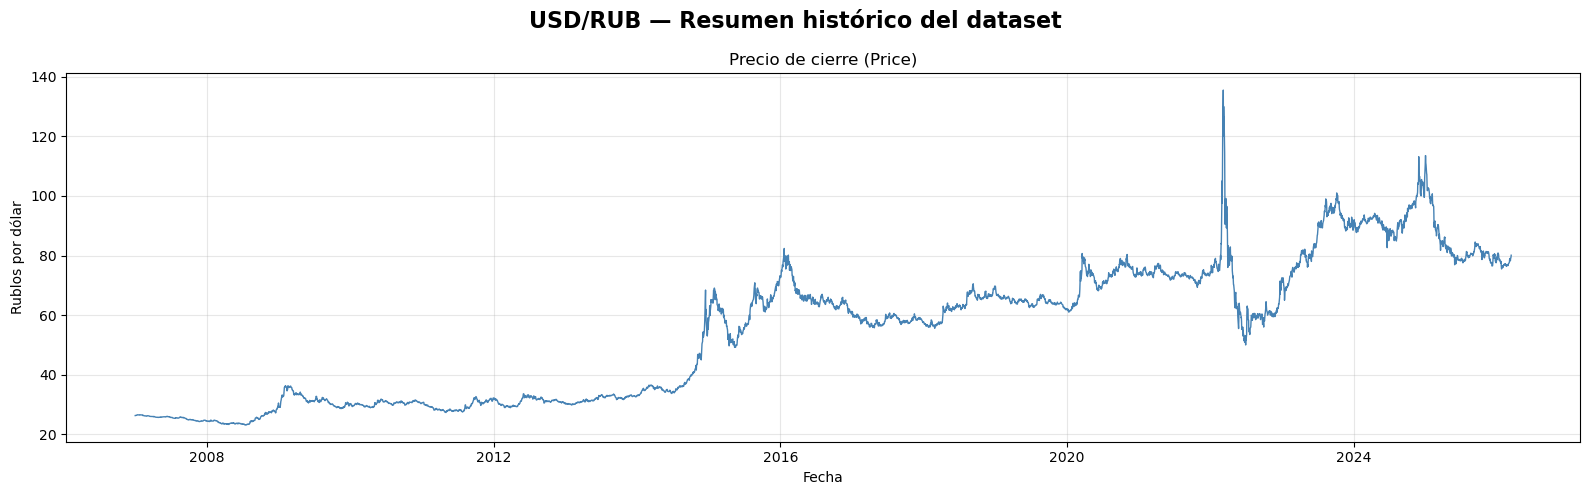

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
fig.suptitle('USD/RUB — Resumen histórico del dataset', fontsize=16, fontweight='bold')

ax.plot(df['Date'], df['Price'], color='steelblue', linewidth=1)
ax.set_title('Precio de cierre (Price)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Rublos por dólar')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
n_steps = 30

def create_windows(data, steps):
    X = np.array([data[i:i + steps] for i in range(len(data) - steps)], dtype=np.float32)
    y = np.array([[data[i + steps, 0]] for i in range(len(data) - steps)], dtype=np.float32)  # target_idx=0 (Price)
    return X, y

n = len(data_raw) - n_steps
train_end = int(n * 0.70)
val_end = int(n * 0.85)

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(data_raw[:train_end + n_steps]) 

data_scaled = scaler.transform(data_raw).astype(np.float32)

X_all, y_all = create_windows(data_scaled, n_steps)
X_train, y_train = X_all[:train_end], y_all[:train_end]
X_valid, y_valid = X_all[train_end:val_end], y_all[train_end:val_end]
X_test, y_test = X_all[val_end:], y_all[val_end:]

y_dates = df['Date'].iloc[n_steps:].reset_index(drop=True)
test_dates = y_dates.iloc[val_end:].reset_index(drop=True)

print(f"\nDatos normalizados")
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Valid: {X_valid.shape}, {y_valid.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")


Datos normalizados
Train: (3488, 30, 5), (3488, 1)
Valid: (748, 30, 5), (748, 1)
Test:  (748, 30, 5), (748, 1)


In [6]:
print(df.describe())


                                Date        Price         Open         High  \
count                           5014  5014.000000  5014.000000  5014.000000   
mean   2016-08-07 06:21:06.533705728    54.617623    54.724883    55.312535   
min              2007-01-01 00:00:00    23.153100    23.157400    23.203500   
25%              2011-10-20 06:00:00    31.060350    31.052500    31.211225   
50%              2016-08-09 12:00:00    59.343000    59.564350    60.427200   
75%              2021-05-24 18:00:00    73.080000    73.267800    73.788275   
max              2026-03-13 00:00:00   135.500000   135.500000   158.300000   
std                              NaN    22.729827    22.824575    23.310682   

               Low     Change %  
count  5014.000000  5014.000000  
mean     54.183935     0.029962  
min      23.055000   -13.540000  
25%      30.923425    -0.420000  
50%      58.954800     0.000000  
75%      72.776700     0.450000  
max     125.500000    20.430000  
std      22.3896

Nuestro objetivo es **predecir el precio de cierre del día siguiente** a partir de los `n_steps` días anteriores. Si un modelo logra hacer esto con precisión, podría ser útil como señal en estrategias de análisis financiero o para monitorear la volatilidad del tipo de cambio USD/RUB.


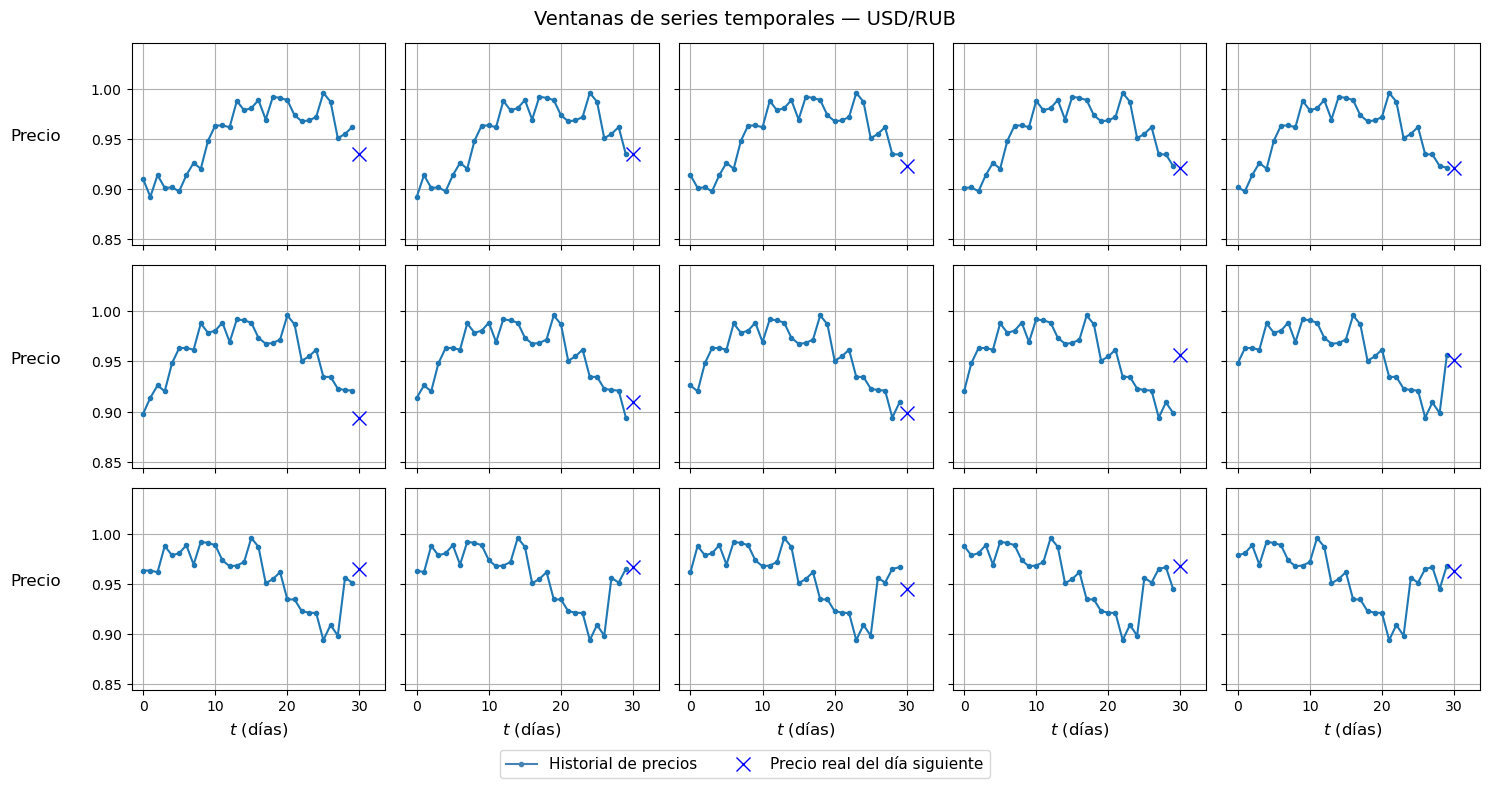

In [7]:
# Visualizar 15 ventanas del conjunto de prueba USD/RUB con su valor objetivo (cruz azul)
# El eje Y muestra el precio normalizado [0, 1]; la 'x' azul es el precio real del día siguiente
plot_series(X_test, y_test, x_label="$t$ (días)", y_label="Precio")


### Predicción *Naive*

Un modelo de referencia muy sencillo consiste en predecir que el precio del día siguiente será igual al precio del último día conocido. A pesar de su simplicidad, este modelo puede ser difícil de superar en series financieras con poca volatilidad a corto plazo.


In [8]:
from sklearn.metrics import mean_squared_error

# Predicción naive: el precio del día siguiente = último precio conocido de la ventana
y_pred_naive = X_test[:, -1, 0].reshape(-1, 1)
mean_squared_error(y_test, y_pred_naive)


0.00033720352803356946

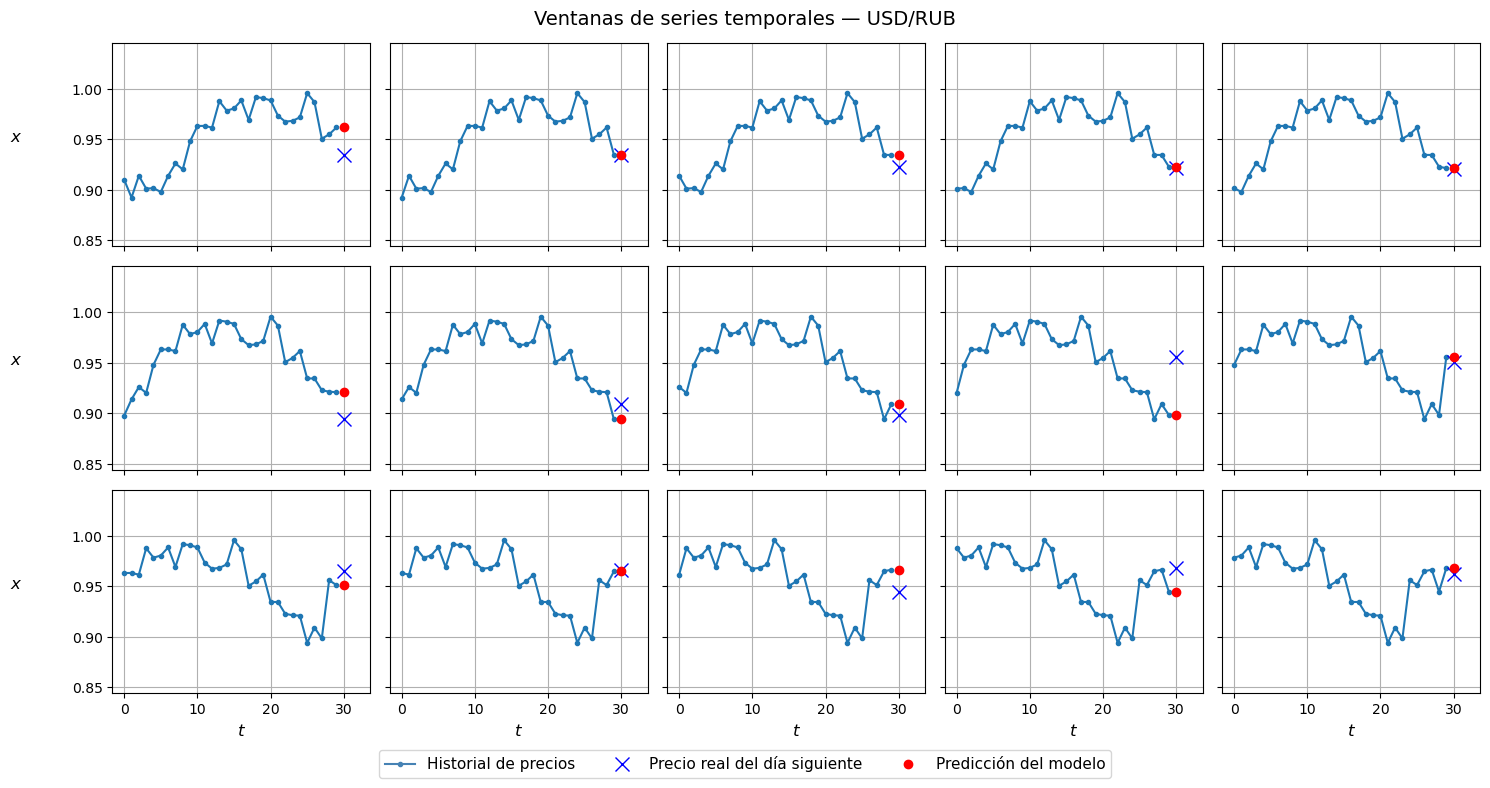

In [9]:
plot_series(X_test, y_test, y_pred_naive)


Como se puede ver, este modelo tan simple tiene un rendimiento razonable: en series financieras, el precio del día anterior suele ser una buena estimación del precio del día siguiente. Este resultado es el **umbral mínimo** que cualquier modelo más complejo debería superar.


### Perceptrón Multicapa

Dado que todas las ventanas tienen la misma longitud (`n_steps`), podemos intentar resolver el problema con un `MLP` estándar. Aunque no captura dependencias temporales de forma explícita, puede aprender correlaciones lineales útiles si los patrones son suficientemente regulares.


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
  def __init__(self, X, y=None, train=True):
    self.X = X
    self.y = y
    self.train = train

  def __len__(self):
    return len(self.X)

  def __getitem__(self, ix):
    if self.train:
      return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
    return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, y_train),
    'eval': TimeSeriesDataset(X_valid, y_valid),
    'test': TimeSeriesDataset(X_test, y_test, train=False)
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=False, batch_size=16),
    'eval': DataLoader(dataset['eval'], shuffle=False, batch_size=16),
    'test': DataLoader(dataset['test'], shuffle=False, batch_size=16)
}

In [11]:
class MLP(torch.nn.Module):
  def __init__(self, n_steps=30, n_features=5, n_out=1):
    super().__init__()
    
    self.fc = torch.nn.Sequential(
        torch.nn.Linear(n_steps * n_features, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, n_out)

    )

  def forward(self, x):
    x = x.view(x.shape[0], -1)
    x = self.fc(x)
    return x

mlp = MLP(n_steps=n_steps, n_features=X_train.shape[2])
mlp

MLP(
  (fc): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [12]:
from tqdm import tqdm
device = "cuda" if torch.cuda.is_available() else "cpu"

def fit(model, dataloader, epochs=250, early_stopping=20, lr=None, batch_size=None):
    model.to(device)
    
    if lr is None:
        has_lstm = any(isinstance(m, torch.nn.LSTM) for m in model.modules())
        lr = 5e-4 if has_lstm else 1e-4
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.6, patience=8, verbose=True)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs+1))
    best_loss, step = float('inf'), 0
    
    for epoch in bar:
        model.train()
        train_loss, train_acc = [], []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss.append(loss.item())
            train_acc.append((torch.abs(y_hat - y) < 0.10).float().mean().item())
        
        model.eval()
        eval_loss, eval_acc = [], []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                eval_loss.append(loss.item())
                eval_acc.append((torch.abs(y_hat - y) < 0.10).float().mean().item())
        
        mean_train_loss = np.mean(train_loss)
        mean_eval_loss = np.mean(eval_loss)
        mean_train_acc = np.mean(train_acc)
        mean_eval_acc = np.mean(eval_acc)
        bar.set_description(f"loss {mean_train_loss:.5f} val_loss {mean_eval_loss:.5f} acc {mean_train_acc:.5f} val_acc {mean_eval_acc:.5f}")
        
        scheduler.step(mean_eval_loss)
        
        if mean_eval_loss < best_loss:
            best_loss = mean_eval_loss
            step = 0
        else:
            step += 1
        
        if early_stopping and step > early_stopping:
            break

def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X = batch
            X = X.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
        return preds


In [13]:
print("Entrenando MLP...")
fit(mlp, dataloader, epochs=250, early_stopping=10)


Entrenando MLP...


d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
loss 0.00019 val_loss 0.00233 acc 0.99914 val_acc 0.96809: 100%|██████████| 250/250 [02:11<00:00,  1.90it/s]


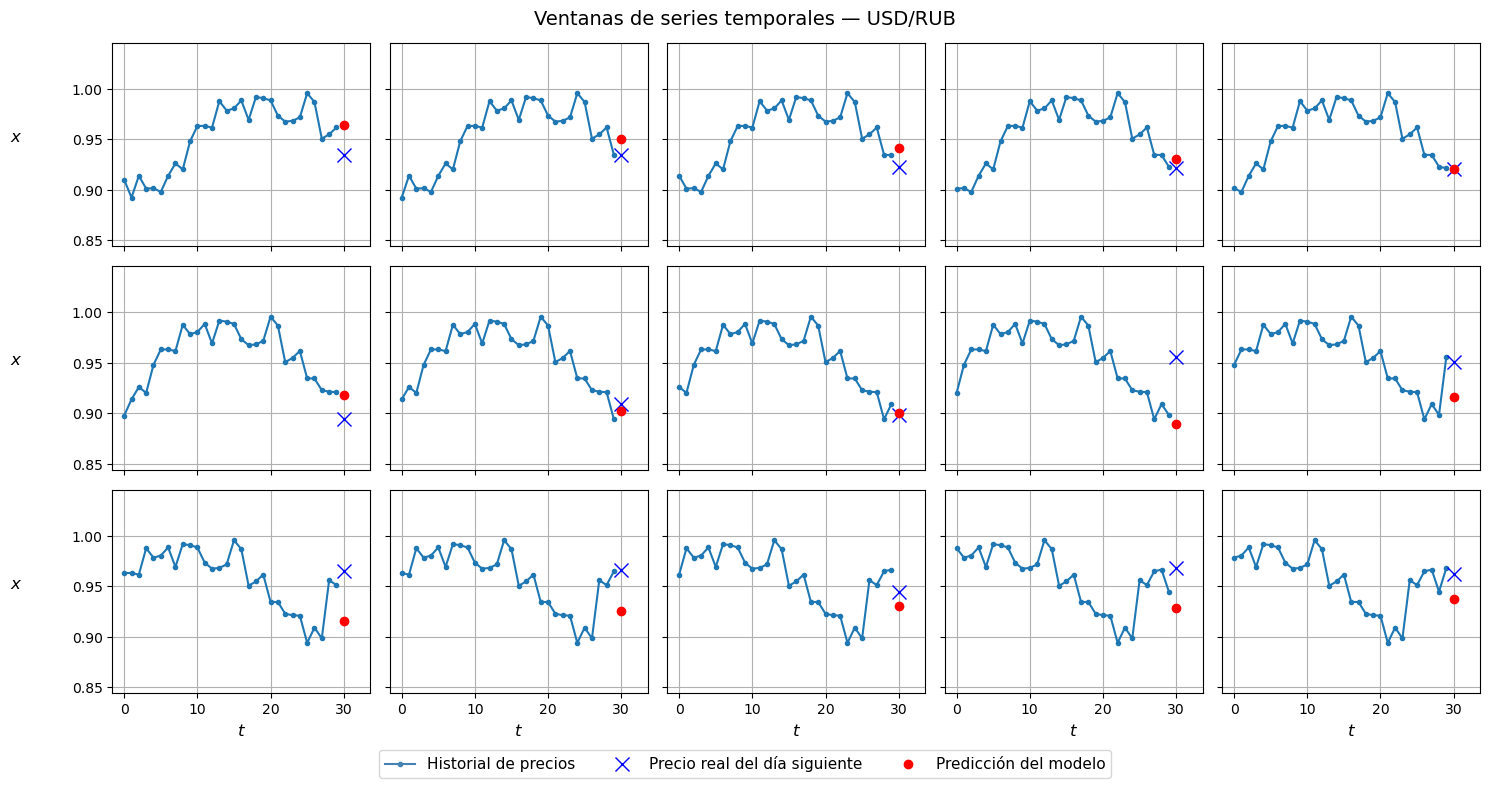

0.0012142120394855738

In [14]:
y_pred = predict(mlp, dataloader['test'])
plot_series(X_test, y_test, y_pred.cpu().numpy())
mean_squared_error(y_test, y_pred.cpu().numpy())


El `MLP` logra mejorar (o al menos igualar) la predicción ingenua. Este modelo es más práctico para **pronóstico autoregresivo**, donde cada predicción se usa como entrada para el siguiente día, permitiendo proyectar indefinidamente hacia el futuro.

## Pronóstico Futuro: Predicción Autoregresiva

Implementamos un enfoque **many-to-one autoregresivo**, este diseño es más práctico para **predecir valores futuros** porque permite generar pronósticos a cualquier horizonte mediante iteración: cada predicción se usa como entrada para el siguiente día, sin limitarse a los datos conocidos del dataset.

In [15]:
horizon = 30

last_window = data_scaled[-n_steps:].astype(np.float32).copy()
future_scaled = []

mlp.eval()
for _ in range(horizon):
    x_in = torch.from_numpy(last_window).unsqueeze(0).to(device=device, dtype=torch.float32)
    
    with torch.no_grad():
        next_scaled = mlp(x_in).item()      
    
    next_scaled = float(np.clip(next_scaled, 0.0, 1.0))
    future_scaled.append(next_scaled)
    
    new_row = last_window[-1].copy().reshape(1, -1)
    new_row[0, 0] = next_scaled
    last_window = np.concatenate([last_window[1:], new_row], axis=0).astype(np.float32)

price_min = scaler.data_min_[0]
price_range = scaler.data_range_[0]
future_prices = np.array(future_scaled) * price_range + price_min

today = pd.Timestamp('2026-03-13')
future_dates = pd.date_range(start=today + pd.Timedelta(days=1), periods=horizon, freq='D')

future_df = pd.DataFrame({
    'Date': future_dates,
    'Prediccion_USD_RUB': future_prices,
})

print(f"PRONÓSTICO A {horizon} DÍAS - MODELO MLP")
print(future_df)
print(f"\nÚltimo precio histórico (13 de marzo 2026): {df['Price'].iloc[-1]:.4f} RUB/USD")
print(f"Precio predicho día {horizon}: {future_df['Prediccion_USD_RUB'].iloc[-1]:.4f} RUB/USD")


PRONÓSTICO A 30 DÍAS - MODELO MLP
         Date  Prediccion_USD_RUB
0  2026-03-14           79.358112
1  2026-03-15           79.491338
2  2026-03-16           79.816602
3  2026-03-17           79.966911
4  2026-03-18           80.048720
5  2026-03-19           80.219627
6  2026-03-20           80.247379
7  2026-03-21           80.360314
8  2026-03-22           80.401136
9  2026-03-23           80.438852
10 2026-03-24           80.390964
11 2026-03-25           80.453979
12 2026-03-26           80.339187
13 2026-03-27           80.390449
14 2026-03-28           80.381759
15 2026-03-29           80.228627
16 2026-03-30           80.219899
17 2026-03-31           80.132943
18 2026-04-01           80.022419
19 2026-04-02           79.862548
20 2026-04-03           79.870398
21 2026-04-04           79.723100
22 2026-04-05           79.681565
23 2026-04-06           79.633748
24 2026-04-07           79.442099
25 2026-04-08           79.424797
26 2026-04-09           79.289319
27 2026-04-10 


Últimos 180 registros: desde 2025-07-07 hasta 2026-03-13


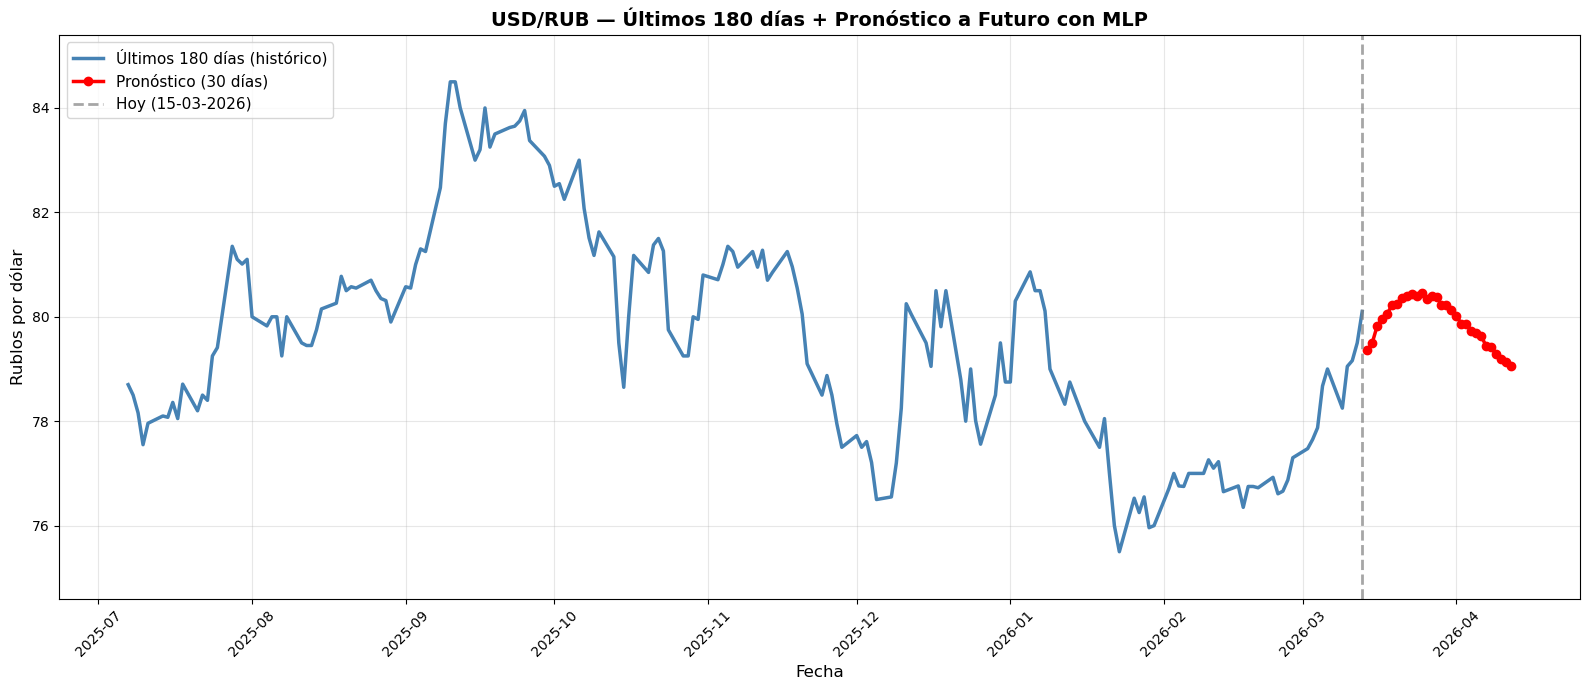

In [16]:
plt.figure(figsize=(16, 7))

today = pd.Timestamp('2026-03-13')

historical_recent = df.tail(180)

print(f"\nÚltimos 180 registros: desde {historical_recent['Date'].iloc[0].date()} hasta {historical_recent['Date'].iloc[-1].date()}")

plt.plot(historical_recent['Date'], historical_recent['Price'], linewidth=2.5, color='steelblue', label='Últimos 180 días (histórico)')

plt.plot(future_df['Date'], future_df['Prediccion_USD_RUB'], 'o-', 
         linewidth=2.5, color='red', markersize=6, label='Pronóstico (30 días)')

plt.axvline(today, color='gray', linestyle='--', alpha=0.7, linewidth=2, label='Hoy (15-03-2026)')

all_prices = np.concatenate([historical_recent['Price'].values, future_df['Prediccion_USD_RUB'].values])
y_min, y_max = all_prices.min(), all_prices.max()
y_margin = (y_max - y_min) * 0.1
plt.ylim(y_min - y_margin, y_max + y_margin)

plt.title('USD/RUB — Últimos 180 días + Pronóstico a Futuro con MLP', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Rublos por dólar', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Red Neuronal Recurrente: LSTM (Long Short-Term Memory)

El **LSTM** es una mejora fundamental sobre las RNN tradicionales. Mientras que las RNN simples sufren del problema de gradientes desvanecientes, el LSTM introduce **compuertas** (gates) que controlan el flujo de información:

- **Puerta de olvido (Forget Gate)**: Decide qué información descartar del estado de largo plazo
- **Puerta de entrada (Input Gate)**: Decide qué nueva información añadir al estado de largo plazo
- **Puerta de salida (Output Gate)**: Decide qué información del estado interno pasar al siguiente paso

Esta arquitectura permite mantener dependencias a largo plazo de forma efectiva, lo que resulta en mejor rendimiento en series temporales comparado con el MLP.

In [17]:
class LSTM(torch.nn.Module):
    def __init__(self, input_size=5, hidden_size=128, num_layers=1, output_size=1, dropout=0.0):
        super().__init__()
        self.lstm = torch.nn.LSTM(input_size=input_size, hidden_size=hidden_size, 
                                   num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = torch.nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        lstm_out, (h, c) = self.lstm(x)
        y = self.fc(lstm_out[:, -1])
        return y

lstm_model = LSTM(input_size=X_train.shape[2], hidden_size=128, num_layers=1, output_size=1, dropout=0.0)
print("Modelo LSTM:")
print(lstm_model)


Modelo LSTM:
LSTM(
  (lstm): LSTM(5, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [18]:
print("Entrenando modelo LSTM")
fit(lstm_model, dataloader, epochs=500, early_stopping=60)


Entrenando modelo LSTM


d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
loss 0.00009 val_loss 0.00129 acc 0.99914 val_acc 0.98404: 100%|██████████| 500/500 [06:22<00:00,  1.31it/s]


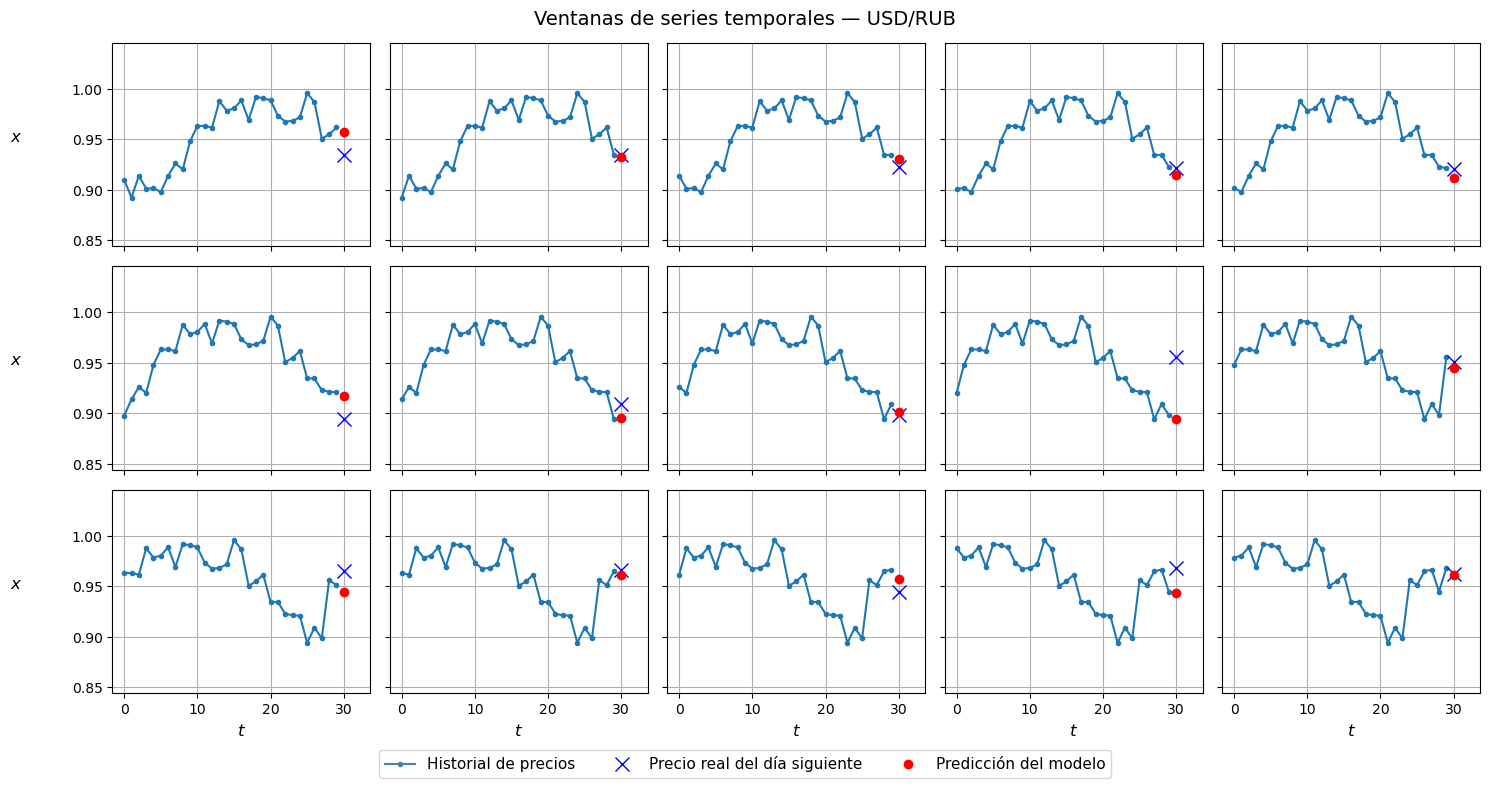


MSE LSTM: 0.00082344
RMSE LSTM: 0.02869565


In [19]:
y_pred_lstm = predict(lstm_model, dataloader['test']).cpu().numpy()
plot_series(X_test, y_test, y_pred_lstm)
mse_lstm = mean_squared_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
print(f"\nMSE LSTM: {mse_lstm:.8f}")
print(f"RMSE LSTM: {rmse_lstm:.8f}")


## Comparativa: MLP vs LSTM

En esta sección comparamos el desempeño de los dos modelos principales: el **Perceptrón Multicapa (MLP)** y el **LSTM**. Ambos fueron entrenados con datos normalizados localmente (`create_sequences_local_norm`) para predecir el precio del día siguiente del USD/RUB.

In [20]:
y_pred_mlp = predict(mlp, dataloader['test']).cpu().numpy()
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
mae_mlp = np.mean(np.abs(y_test - y_pred_mlp))

mae_lstm = np.mean(np.abs(y_test - y_pred_lstm))

comparison_table = pd.DataFrame({
    'Modelo': ['MLP', 'LSTM'],
    'MSE': [mse_mlp, mse_lstm],
    'RMSE': [rmse_mlp, rmse_lstm],
    'MAE': [mae_mlp, mae_lstm],
    'Parámetros': ['MLP (feed-forward)', 'LSTM con compuertas'],
    'Capas': ['1 oculta', '2 LSTM + 1 FC']
})

print("COMPARATIVA DE MODELOS: MLP vs LSTM")
print(comparison_table.to_string(index=False))

mejora_mse = ((mse_mlp - mse_lstm) / mse_mlp) * 100
mejora_rmse = ((rmse_mlp - rmse_lstm) / rmse_mlp) * 100
mejora_mae = ((mae_mlp - mae_lstm) / mae_mlp) * 100

print(f"\nMEJORA DEL LSTM SOBRE MLP:")
print(f"   • MSE:  {mejora_mse:+.2f}% {'✓ mejor' if mejora_mse > 0 else '✗ peor'}")
print(f"   • RMSE: {mejora_rmse:+.2f}% {'✓ mejor' if mejora_rmse > 0 else '✗ peor'}")
print(f"   • MAE:  {mejora_mae:+.2f}% {'✓ mejor' if mejora_mae > 0 else '✗ peor'}")

COMPARATIVA DE MODELOS: MLP vs LSTM
Modelo      MSE     RMSE      MAE          Parámetros         Capas
   MLP 0.001214 0.034846 0.027082  MLP (feed-forward)      1 oculta
  LSTM 0.000823 0.028696 0.021252 LSTM con compuertas 2 LSTM + 1 FC

MEJORA DEL LSTM SOBRE MLP:
   • MSE:  +32.18% ✓ mejor
   • RMSE: +17.65% ✓ mejor
   • MAE:  +21.53% ✓ mejor


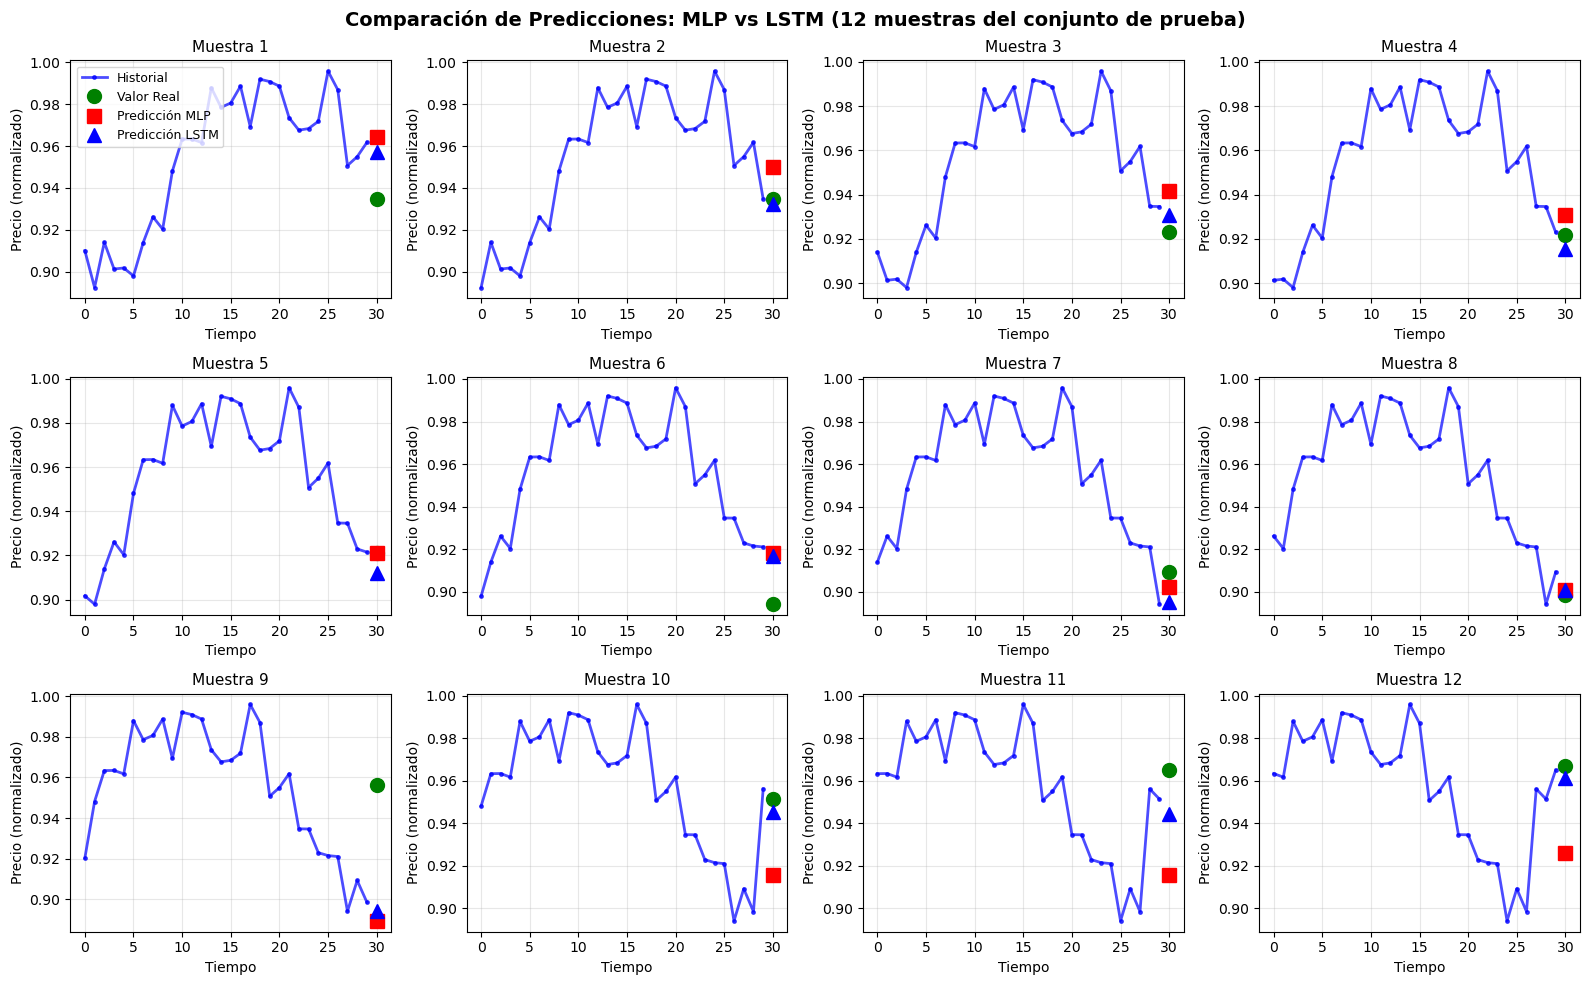

In [28]:

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for idx in range(12):
    ax = axes[idx]
    
    x_seq = X_test[idx, :, 0]
    ax.plot(x_seq, 'b.-', label='Historial', linewidth=2, markersize=5, alpha=0.7)
    
    ax.plot([len(x_seq)], y_test[idx], 'go', markersize=10, label='Valor Real', zorder=5)
    ax.plot([len(x_seq)], y_pred_mlp[idx], 'rs', markersize=10, label='Predicción MLP', zorder=5)
    ax.plot([len(x_seq)], y_pred_lstm[idx], 'b^', markersize=10, label='Predicción LSTM', zorder=5)
    
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Muestra {idx+1}', fontsize=11)
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Precio (normalizado)')
    if idx == 0:
        ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Comparación de Predicciones: MLP vs LSTM (12 muestras del conjunto de prueba)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

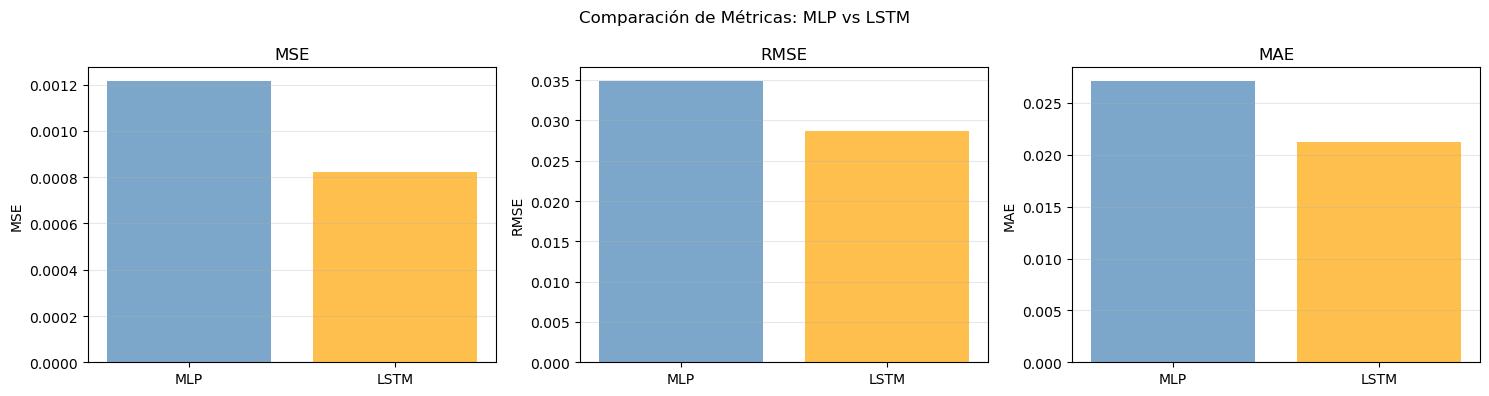

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.bar(['MLP', 'LSTM'], [mse_mlp, mse_lstm], color=['steelblue', 'orange'], alpha=0.7)
ax.set_ylabel('MSE')
ax.set_title('MSE')
ax.grid(axis='y', alpha=0.3)    

ax = axes[1]
ax.bar(['MLP', 'LSTM'], [rmse_mlp, rmse_lstm], color=['steelblue', 'orange'], alpha=0.7)
ax.set_ylabel('RMSE')
ax.set_title('RMSE')
ax.grid(axis='y', alpha=0.3)

ax = axes[2]
ax.bar(['MLP', 'LSTM'], [mae_mlp, mae_lstm], color=['steelblue', 'orange'], alpha=0.7)
ax.set_ylabel('MAE')
ax.set_title('MAE')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparación de Métricas: MLP vs LSTM')
plt.tight_layout()
plt.show()

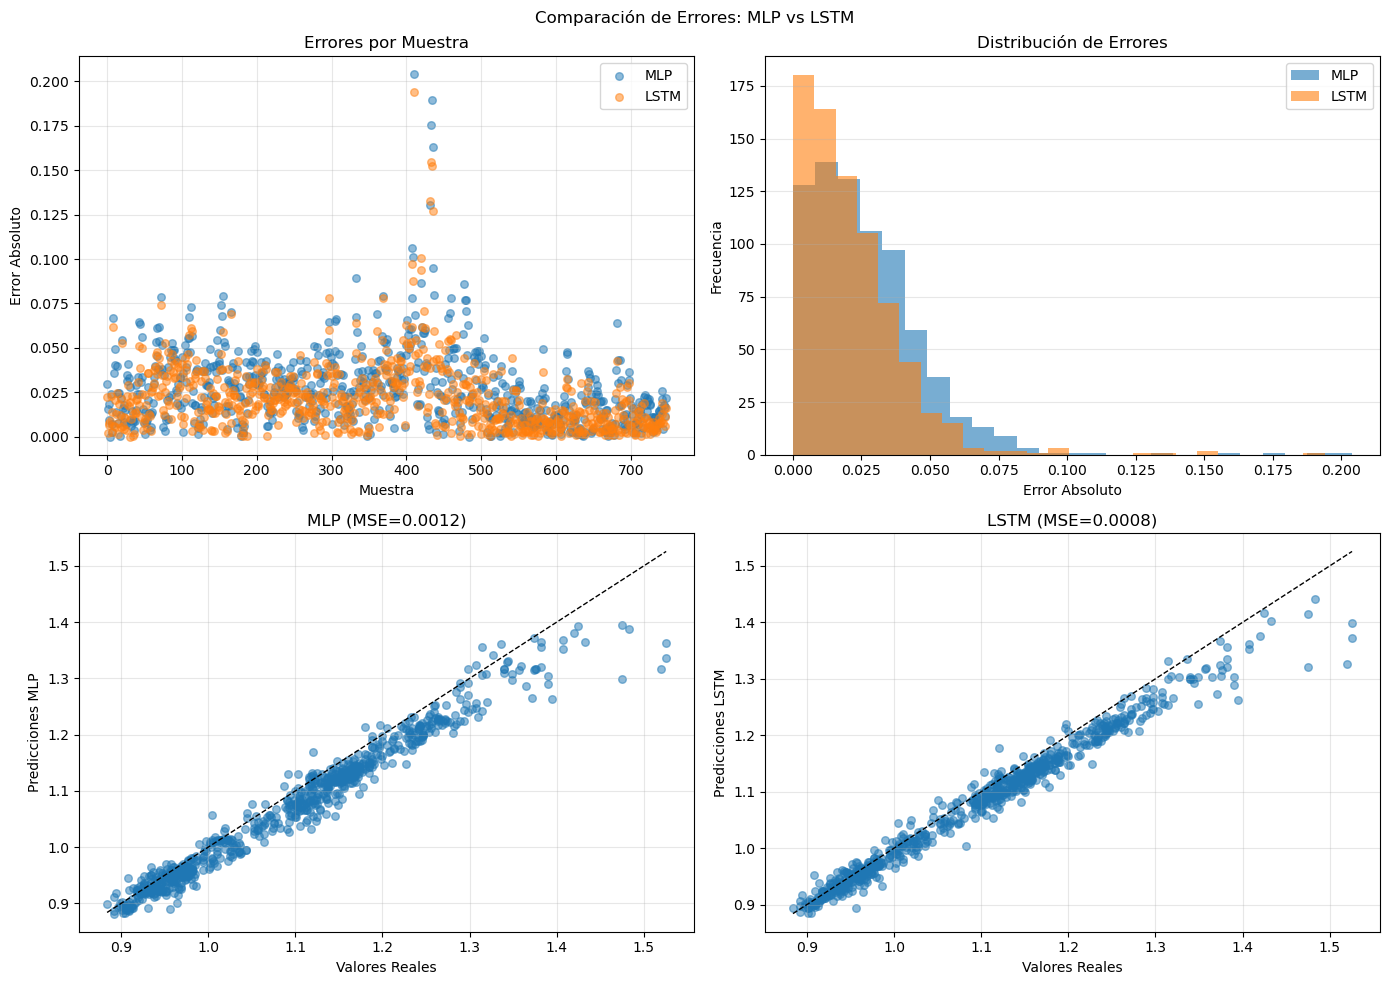

In [23]:
errores_mlp = np.abs(y_test.flatten() - y_pred_mlp.flatten())
errores_lstm = np.abs(y_test.flatten() - y_pred_lstm.flatten())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.scatter(range(len(errores_mlp)), errores_mlp, alpha=0.5, s=30, label='MLP')
ax.scatter(range(len(errores_lstm)), errores_lstm, alpha=0.5, s=30, label='LSTM')
ax.set_xlabel('Muestra')
ax.set_ylabel('Error Absoluto')
ax.set_title('Errores por Muestra')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.hist(errores_mlp, bins=25, alpha=0.6, label='MLP')
ax.hist(errores_lstm, bins=25, alpha=0.6, label='LSTM')
ax.set_xlabel('Error Absoluto')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Errores')
ax.legend()
ax.grid(axis='y', alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test, y_pred_mlp, alpha=0.5, s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
ax.set_xlabel('Valores Reales')
ax.set_ylabel('Predicciones MLP')
ax.set_title(f'MLP (MSE={mse_mlp:.4f})')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.scatter(y_test, y_pred_lstm, alpha=0.5, s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
ax.set_xlabel('Valores Reales')
ax.set_ylabel('Predicciones LSTM')
ax.set_title(f'LSTM (MSE={mse_lstm:.4f})')
ax.grid(True, alpha=0.3)

plt.suptitle('Comparación de Errores: MLP vs LSTM')
plt.tight_layout()
plt.show()

## Pronóstico Futuro LSTM: Predicción Autoregresiva a 30 Días

In [24]:
horizon = 30

last_window = data_scaled[-n_steps:].astype(np.float32).copy()
future_scaled_lstm = []

lstm_model.eval()
for _ in range(horizon):
    x_in = torch.from_numpy(last_window).unsqueeze(0).to(device=device, dtype=torch.float32)
    
    with torch.no_grad():
        next_scaled = lstm_model(x_in).item()      
    
    next_scaled = float(np.clip(next_scaled, 0.0, 1.0))
    future_scaled_lstm.append(next_scaled)
    
    new_row = last_window[-1].copy().reshape(1, -1)
    new_row[0, 0] = next_scaled
    last_window = np.concatenate([last_window[1:], new_row], axis=0).astype(np.float32)

price_min = scaler.data_min_[0]
price_range = scaler.data_range_[0]
future_prices_lstm = np.array(future_scaled_lstm) * price_range + price_min

today = pd.Timestamp('2026-03-13')
future_dates = pd.date_range(start=today + pd.Timedelta(days=1), periods=horizon, freq='D')

future_df_lstm = pd.DataFrame({
    'Date': future_dates,
    'Prediccion_USD_RUB_LSTM': future_prices_lstm,
})

print(f"PRONÓSTICO A {horizon} DÍAS - MODELO LSTM")
print(future_df_lstm)
print(f"\nÚltimo precio histórico (13 de marzo 2026): {df['Price'].iloc[-1]:.4f} RUB/USD")
print(f"Precio predicho día {horizon}: {future_df_lstm['Prediccion_USD_RUB_LSTM'].iloc[-1]:.4f} RUB/USD")


PRONÓSTICO A 30 DÍAS - MODELO LSTM
         Date  Prediccion_USD_RUB_LSTM
0  2026-03-14                79.791091
1  2026-03-15                79.935770
2  2026-03-16                80.003480
3  2026-03-17                80.025726
4  2026-03-18                80.024956
5  2026-03-19                80.014301
6  2026-03-20                79.999971
7  2026-03-21                79.985176
8  2026-03-22                79.970832
9  2026-03-23                79.957537
10 2026-03-24                79.944707
11 2026-03-25                79.932742
12 2026-03-26                79.921233
13 2026-03-27                79.910648
14 2026-03-28                79.900642
15 2026-03-29                79.891229
16 2026-03-30                79.882525
17 2026-03-31                79.873723
18 2026-04-01                79.865478
19 2026-04-02                79.858112
20 2026-04-03                79.851533
21 2026-04-04                79.845349
22 2026-04-05                79.839748
23 2026-04-06                


Últimos 180 registros: desde 2025-07-07 hasta 2026-03-13


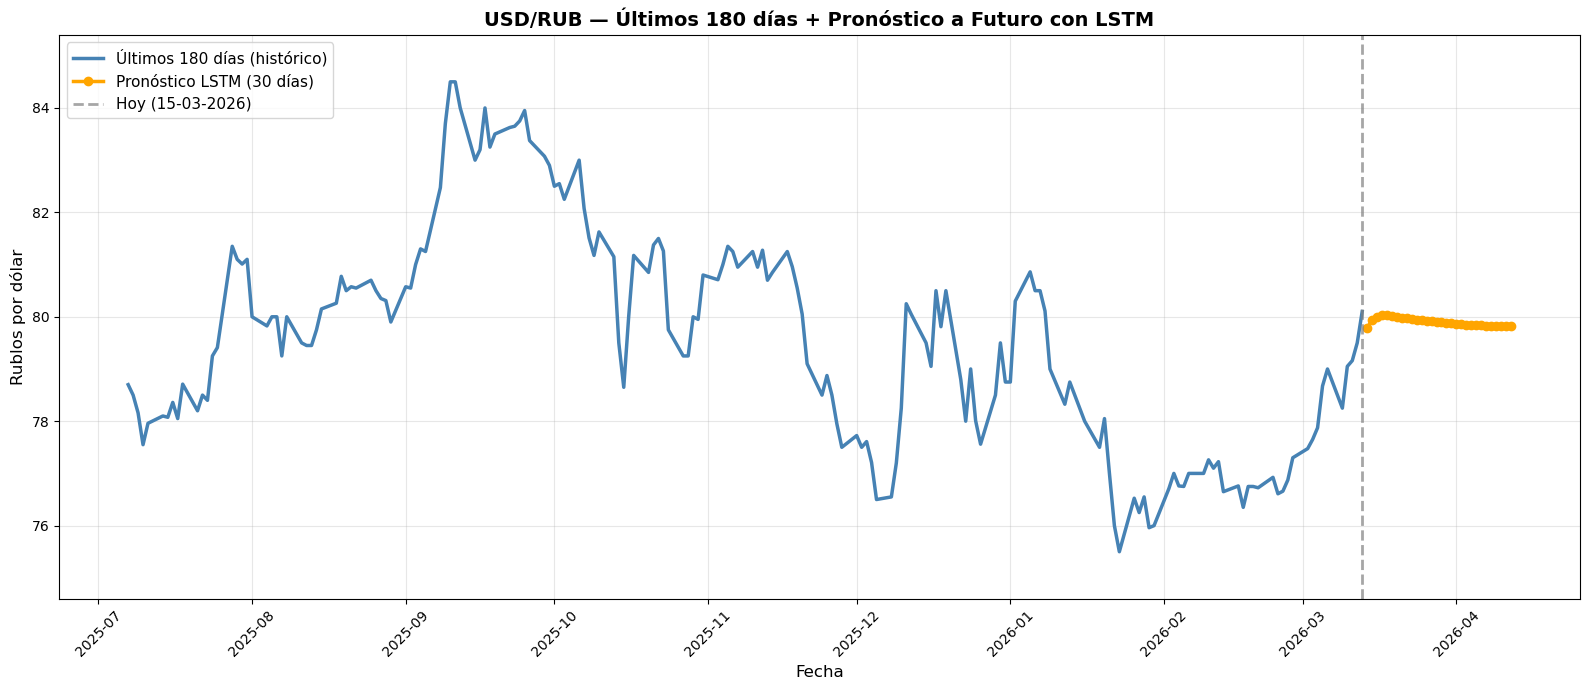

In [25]:
plt.figure(figsize=(16, 7))

today = pd.Timestamp('2026-03-13')

historical_recent = df.tail(180)

print(f"\nÚltimos 180 registros: desde {historical_recent['Date'].iloc[0].date()} hasta {historical_recent['Date'].iloc[-1].date()}")

plt.plot(historical_recent['Date'], historical_recent['Price'], linewidth=2.5, color='steelblue', label='Últimos 180 días (histórico)')

plt.plot(future_df_lstm['Date'], future_df_lstm['Prediccion_USD_RUB_LSTM'], 'o-', 
         linewidth=2.5, color='orange', markersize=6, label='Pronóstico LSTM (30 días)')

plt.axvline(today, color='gray', linestyle='--', alpha=0.7, linewidth=2, label='Hoy (15-03-2026)')

all_prices = np.concatenate([historical_recent['Price'].values, future_df_lstm['Prediccion_USD_RUB_LSTM'].values])
y_min, y_max = all_prices.min(), all_prices.max()
y_margin = (y_max - y_min) * 0.1
plt.ylim(y_min - y_margin, y_max + y_margin)

plt.title('USD/RUB — Últimos 180 días + Pronóstico a Futuro con LSTM', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Rublos por dólar', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

# Reconocimiento de Actividades Humanas con LSTM Bidireccional

En esta sección trabajaremos con el dataset **UCI Human Activity Recognition Using Smartphones**. Este dataset contiene datos de acelerómetro y giroscopio de smartphones para clasificar actividades humanas (caminar, subir escaleras, sentarse, etc.). Utilizaremos un modelo **LSTM Bidireccional** que puede procesar la información tanto hacia adelante como hacia atrás para realizar clasificación de secuencias.

In [ ]:
har_path = 'UCI HAR Dataset/'

X_train_har = np.loadtxt(har_path + 'train/X_train.txt')
y_train_har = np.loadtxt(har_path + 'train/y_train.txt').astype(int) - 1
subject_train_har = np.loadtxt(har_path + 'train/subject_train.txt').astype(int)

X_test_har = np.loadtxt(har_path + 'test/X_test.txt')
y_test_har = np.loadtxt(har_path + 'test/y_test.txt').astype(int) - 1
subject_test_har = np.loadtxt(har_path + 'test/subject_test.txt').astype(int)

with open(har_path + 'activity_labels.txt', 'r') as f:
    activities = {}
    for line in f:
        parts = line.strip().split(maxsplit=1)
        if len(parts) == 2:
            activities[int(parts[0]) - 1] = parts[1]

print(f"Conjunto de entrenamiento: {X_train_har.shape}")
print(f"Conjunto de prueba: {X_test_har.shape}")
print(f"Número de actividades: {len(activities)}")
print(f"\nActividades: {activities}")



n_features = X_train_har.shape[1]
n_samples_train = X_train_har.shape[0]
n_samples_test = X_test_har.shape[0]

print(f"\nNúmero de features: {n_features}")
print(f"Número de muestras de entrenamiento: {n_samples_train}")
print(f"Número de muestras de prueba: {n_samples_test}")


Conjunto de entrenamiento: (7352, 561)
Conjunto de prueba: (2947, 561)
Número de actividades: 6

Actividades: {0: 'WALKING', 1: 'WALKING_UPSTAIRS', 2: 'WALKING_DOWNSTAIRS', 3: 'SITTING', 4: 'STANDING', 5: 'LAYING'}

Número de features: 561
Número de muestras de entrenamiento: 7352
Número de muestras de prueba: 2947


In [31]:
scaler_har = MinMaxScaler(feature_range=(0, 1))
X_train_har_scaled = scaler_har.fit_transform(X_train_har).astype(np.float32)
X_test_har_scaled = scaler_har.transform(X_test_har).astype(np.float32)

X_train_har_seq = X_train_har_scaled[:, np.newaxis, :]  
X_test_har_seq = X_test_har_scaled[:, np.newaxis, :]

print(f"X_train_har_seq shape: {X_train_har_seq.shape}")
print(f"X_test_har_seq shape: {X_test_har_seq.shape}")
print(f"y_train_har shape: {y_train_har.shape}")
print(f"y_test_har shape: {y_test_har.shape}")

class HAR_Dataset(Dataset):
  def __init__(self, X, y=None, train=True):
    self.X = X
    self.y = y
    self.train = train

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    if self.train:
      return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx], dtype=torch.long)
    return torch.from_numpy(self.X[idx])

train_size = int(0.8 * len(X_train_har_seq))
val_size = len(X_train_har_seq) - train_size

indices = np.random.permutation(len(X_train_har_seq))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

X_train, y_train = X_train_har_seq[train_indices], y_train_har[train_indices]
X_val, y_val = X_train_har_seq[val_indices], y_train_har[val_indices]

dataset_har = {
    'train': HAR_Dataset(X_train, y_train),
    'eval': HAR_Dataset(X_val, y_val),
    'test': HAR_Dataset(X_test_har_seq, y_test_har, train=False)
}

dataloader_har = {
    'train': DataLoader(dataset_har['train'], shuffle=True, batch_size=32),
    'eval': DataLoader(dataset_har['eval'], shuffle=False, batch_size=32),
    'test': DataLoader(dataset_har['test'], shuffle=False, batch_size=32)
}

print(f"\nTamaño del conjunto de entrenamiento: {len(X_train)}")
print(f"Tamaño del conjunto de validación: {len(X_val)}")
print(f"Tamaño del conjunto de prueba: {len(X_test_har_seq)}")


X_train_har_seq shape: (7352, 1, 561)
X_test_har_seq shape: (2947, 1, 561)
y_train_har shape: (7352,)
y_test_har shape: (2947,)

Tamaño del conjunto de entrenamiento: 5881
Tamaño del conjunto de validación: 1471
Tamaño del conjunto de prueba: 2947


In [32]:
class BidirectionalLSTM(torch.nn.Module):
    def __init__(self, input_size=561, hidden_size=128, num_layers=2, num_classes=6, dropout=0.3):
        super().__init__()
        self.lstm = torch.nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=dropout,
            bidirectional=True  
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(hidden_size * 2, 256), 
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        lstm_out, (h, c) = self.lstm(x)
        x = lstm_out[:, -1, :]
        x = self.fc(x)
        return x

bidirectional_lstm = BidirectionalLSTM(
    input_size=n_features,
    hidden_size=128,
    num_layers=2,
    num_classes=6,
    dropout=0.3
)

print("Modelo Bidirectional LSTM:")
print(bidirectional_lstm)
print(f"\nNúmero total de parámetros: {sum(p.numel() for p in bidirectional_lstm.parameters()):,}")


Modelo Bidirectional LSTM:
BidirectionalLSTM(
  (lstm): LSTM(561, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)

Número total de parámetros: 1,170,182


In [36]:
def fit_classifier(model, dataloader, epochs=100, early_stopping=15, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=False)
    criterion = torch.nn.CrossEntropyLoss()
    
    bar = tqdm(range(1, epochs+1))
    best_val_acc, step = 0.0, 0
    
    for epoch in bar:
        model.train()
        train_loss, train_acc = [], []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss.append(loss.item())
            pred = y_hat.argmax(dim=1)
            acc = (pred == y).float().mean().item()
            train_acc.append(acc)
        
        model.eval()
        eval_loss, eval_acc = [], []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                eval_loss.append(loss.item())
                
                pred = y_hat.argmax(dim=1)
                acc = (pred == y).float().mean().item()
                eval_acc.append(acc)
        
        mean_train_loss = np.mean(train_loss)
        mean_eval_loss = np.mean(eval_loss)
        mean_train_acc = np.mean(train_acc)
        mean_eval_acc = np.mean(eval_acc)
        
        bar.set_description(f"loss {mean_train_loss:.5f} val_loss {mean_eval_loss:.5f} acc {mean_train_acc:.4f} val_acc {mean_eval_acc:.4f}")
        
        scheduler.step(mean_eval_acc)
        
        if mean_eval_acc > best_val_acc:
            best_val_acc = mean_eval_acc
            step = 0
        else:
            step += 1
        
        if early_stopping and step > early_stopping:
            print(f"Early stopping en epoch {epoch}")
            break

def predict_classifier(model, dataloader):
    model.eval()
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for batch in dataloader:
            X = batch
            X = X.to(device)
            y_hat = model(X)
            probs = torch.softmax(y_hat, dim=1)
            preds = y_hat.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    
    return np.concatenate(all_preds), np.concatenate(all_probs)



In [41]:
print("Entrenando modelo Bidirectional LSTM para clasificación de actividades...")
fit_classifier(bidirectional_lstm, dataloader_har, epochs=150, early_stopping=20, lr=1e-3)

d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Entrenando modelo Bidirectional LSTM para clasificación de actividades...


loss 0.00031 val_loss 0.10673 acc 1.0000 val_acc 0.9871:  43%|████▎     | 64/150 [01:12<01:37,  1.13s/it]

Early stopping en epoch 65


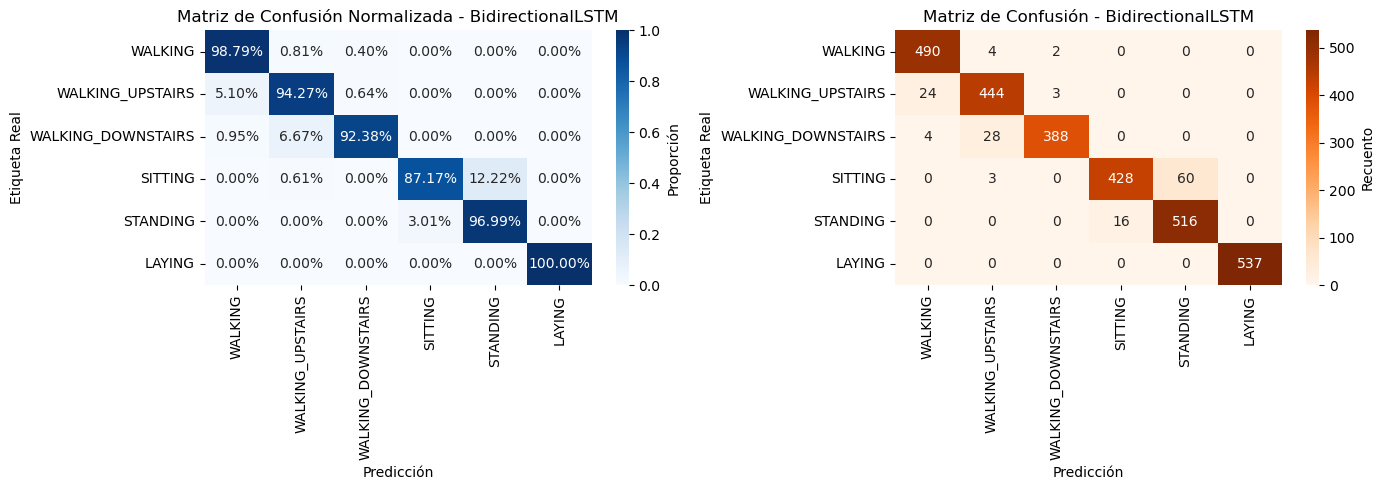

In [43]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=[activities[i] for i in range(6)],
            yticklabels=[activities[i] for i in range(6)],
            ax=axes[0], cbar_kws={'label': 'Proporción'})
axes[0].set_title('Matriz de Confusión Normalizada - BidirectionalLSTM')
axes[0].set_ylabel('Etiqueta Real')
axes[0].set_xlabel('Predicción')

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=[activities[i] for i in range(6)],
            yticklabels=[activities[i] for i in range(6)],
            ax=axes[1], cbar_kws={'label': 'Recuento'})
axes[1].set_title('Matriz de Confusión - BidirectionalLSTM')
axes[1].set_ylabel('Etiqueta Real')
axes[1].set_xlabel('Predicción')

plt.tight_layout()
plt.show()


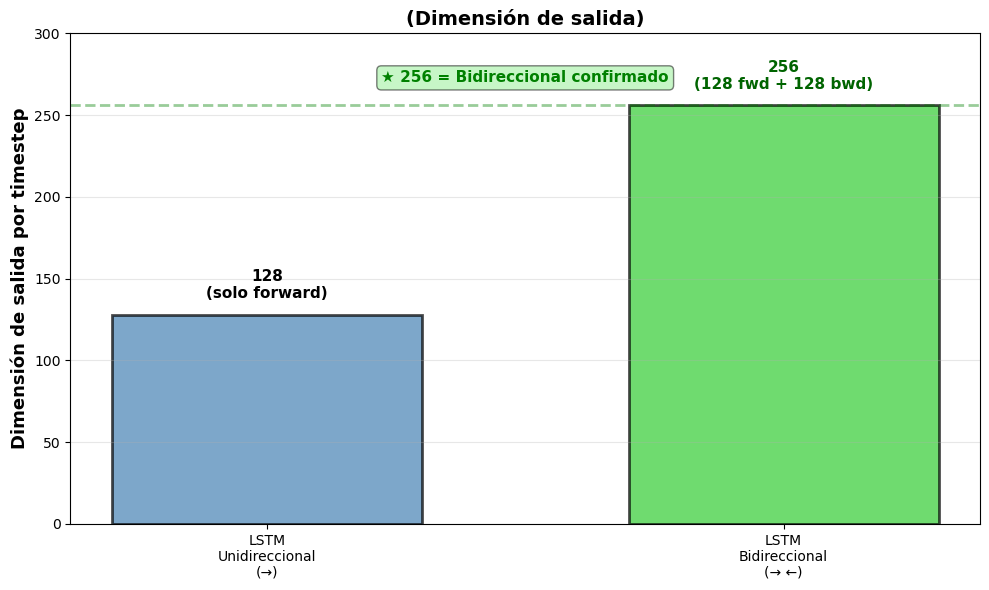

In [51]:

fig, ax = plt.subplots(figsize=(10, 6))

modelos = ['LSTM\nUnidireccional\n(→)', 'LSTM\nBidireccional\n(→ ←)']
dimensiones = [128, 256]
colores = ['steelblue', 'limegreen']

barras = ax.bar(modelos, dimensiones, color=colores, alpha=0.7, edgecolor='black', linewidth=2, width=0.6)

ax.set_ylabel('Dimensión de salida por timestep', fontsize=13, fontweight='bold')
ax.set_ylim(0, 300)
ax.set_title('(Dimensión de salida)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for barra, dim in zip(barras, dimensiones):
    altura = barra.get_height()
    if dim == 128:
        ax.text(barra.get_x() + barra.get_width()/2, altura + 10, 
                '128\n(solo forward)', ha='center', fontsize=11, fontweight='bold')
    else:
        ax.text(barra.get_x() + barra.get_width()/2, altura + 10, 
                '256\n(128 fwd + 128 bwd)', ha='center', fontsize=11, fontweight='bold', color='darkgreen')

# Línea indicadora
ax.axhline(256, color='green', linestyle='--', alpha=0.4, linewidth=2)
ax.text(0.5, 270, '★ 256 = Bidireccional confirmado', fontsize=11, color='green', fontweight='bold', ha='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()
